In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from v2_data_preparation import load_and_prepare_data, process_insitu, slice_by_dates

In [217]:
modeled_fp1 = '../outputs/predictions/SDH1_2000-2026_first-year.csv'
modeled_fp2 = '../outputs/predictions/SDH2_2000-2026_first-year.csv'

observed_fp1 = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
observed_fp2 = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'

In [218]:
modeled_df1 = (
    load_and_prepare_data(modeled_fp1)
    .pipe(slice_by_dates, startDate='2000-03', endDate='2024-05')
)
modeled_df2 = (
    load_and_prepare_data(modeled_fp2)
    .pipe(slice_by_dates, startDate='2000-03', endDate='2024-05')
)

In [219]:
observed_df1 = process_insitu(
    filepath=observed_fp1,
    start_date='2024-06-01',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)
observed_df2 = process_insitu(
    filepath=observed_fp2,
    start_date='2024-06-01',
    end_date='2026-05-14',
    cols_to_keep=['SDH2PP01_gw-depth_m'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)

In [220]:
def plot_annual_regime(
    modeled_df: pd.DataFrame,
    observed_df: pd.DataFrame,
    val_col: str = None,
    show_envelope: bool = True,
):
    """Compara el régimen anual típico (día a día) entre datos modelados y observados.

    Parameters:
    - modeled_df: DataFrame con DatetimeIndex (ej. 2000-2024).
    - observed_df: DataFrame con DatetimeIndex (ej. 2024-2026).
    - val_col: Nombre de la columna con los datos (si es None, toma la primera
    columna).
    - show_envelope: Si es True, grafica el rango intercuartílico (p25-p75) o
    min-max del modelo.
    """
    mod = modeled_df.copy()
    obs = observed_df.copy()

    # Si no se especifica columna, tomar la primera
    if val_col is None:
        col_mod = mod.columns[0]
        col_obs = obs.columns[0]
    else:
        col_mod = val_col
        col_obs = val_col

    # Extraer día del año y omitir día bisiesto (366) para cuadrar en 365 días
    mod["doy"] = mod.index.dayofyear
    obs["doy"] = obs.index.dayofyear

    mod = mod[mod["doy"] <= 365]
    obs = obs[obs["doy"] <= 365]

    # Estadísticas diarias del modelo (representativo de ~24 años)
    mod_stats = (
        mod.groupby("doy")[col_mod]
        .agg(
            mean="mean",
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            val_min="min",
            val_max="max",
        )
        .reindex(range(1, 366))
    )

    # Estadísticas diarias observadas (~2 años)
    obs_stats = (
        obs.groupby("doy")[col_obs]
        .agg(mean="mean", median="median", val_min="min", val_max="max")
        .reindex(range(1, 366))
    )

    # Configuración de la figura
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Envolventes/bandas de dispersión del modelo (si aplica)
    if show_envelope:
        ax.fill_between(
            mod_stats.index,
            mod_stats["q25"],
            mod_stats["q75"],
            color="#1f77b4",
            alpha=0.3,
            label="Modelado (Rango P25–P75)",
        )
        ax.fill_between(
                mod_stats.index,
                mod_stats["val_min"],
                mod_stats["val_max"],
                color="#1f77b4",
                alpha=0.15,
                label="Modelado (Rango min-max)",
            )

    # 2. Línea media modelada (azul)
    ax.plot(
        mod_stats.index,
        mod_stats["median"],
        color="#1f77b4",
        linewidth=2.2,
        label="Modelado (Mediana 2000–2024)",
    )

    # 3. Línea media observada (gris)
    ax.plot(
        obs_stats.index,
        obs_stats["median"],
        color="#555555",
        linewidth=2.2,
        linestyle="-",
        label="Observado (Mediana 2024–2026)",
    )

    # Marcadores de meses en el eje X
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = [
        "Ene",
        "Feb",
        "Mar",
        "Abr",
        "May",
        "Jun",
        "Jul",
        "Ago",
        "Sep",
        "Oct",
        "Nov",
        "Dic",
    ]

    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)
    ax.set_xlim(1, 365)

    ax.set_title(
        "Régimen Típico Anual: Observado vs. Modelado", fontsize=13, pad=12
    )
    ax.set_xlabel("Mes del año", fontsize=11)
    ax.set_ylabel("Nivel freático", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True)

    plt.tight_layout()
    return fig, ax


In [221]:
def plot_annual_regime_monthly(
    modeled_df: pd.DataFrame,
    observed_df: pd.DataFrame,
    val_col: str = None,
    show_envelope: bool = True,
):
    mod = modeled_df.copy()
    obs = observed_df.copy()

    col_mod = val_col if val_col else mod.columns[0]
    col_obs = val_col if val_col else obs.columns[0]

    # 1. Agregación intermedia a escala mensual (un valor por mes-año)
    mod_monthly = mod[[col_mod]].resample("MS").median()
    obs_monthly = obs[[col_obs]].resample("MS").median()

    # 2. Agregación final al "mes tipo" (1 a 12) sobre los meses agregados
    mod_stats = (
        mod_monthly.groupby(mod_monthly.index.month)[col_mod]
        .agg(
            mean="mean",
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            val_min="min",
            val_max="max",
        )
        .reindex(range(1, 13))
    )
    obs_stats = (
        obs_monthly.groupby(obs_monthly.index.month)[col_obs]
        .agg(mean="mean", median="median")
        .reindex(range(1, 13))
    )

    # 3. Graficar
    fig, ax = plt.subplots(figsize=(10, 6))

    # Banda intercuartílica mensual del modelo
    if show_envelope:
        ax.fill_between(
            mod_stats.index,
            mod_stats["q25"],
            mod_stats["q75"],
            color="#1f77b4",
            alpha=0.3,
            label="Modelado (Rango P25–P75)",
        )
        ax.fill_between(
                mod_stats.index,
                mod_stats["val_min"],
                mod_stats["val_max"],
                color="#1f77b4",
                alpha=0.15,
                label="Modelado (Rango min–max)",
            )
    # Curvas mensuales (con marcadores 'o' para resaltar los 12 puntos)
    ax.plot(
        mod_stats.index,
        mod_stats["median"],
        color="#1f77b4",
        linewidth=2.2,
        marker="o",
        label="Modelado (Mediana 2000–2024)",
    )
    ax.plot(
        obs_stats.index,
        obs_stats["median"],
        color="#555555",
        linewidth=2.2,
        marker="s",
        label="Observado (Mediana 2024–2026)",
    )

    # 4. Configurar eje X para 12 meses discretos
    months = list(range(1, 13))
    month_names = [
        "Ene",
        "Feb",
        "Mar",
        "Abr",
        "May",
        "Jun",
        "Jul",
        "Ago",
        "Sep",
        "Oct",
        "Nov",
        "Dic",
    ]

    ax.set_xticks(months)
    ax.set_xticklabels(month_names)
    ax.set_xlim(0.5, 12.5)

    ax.set_title(
        "Régimen Medio Mensual: Observado vs. Modelado", fontsize=13, pad=12
    )
    ax.set_xlabel("Mes", fontsize=11)
    ax.set_ylabel("Nivel freático", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", frameon=True)

    plt.tight_layout()
    return fig, ax


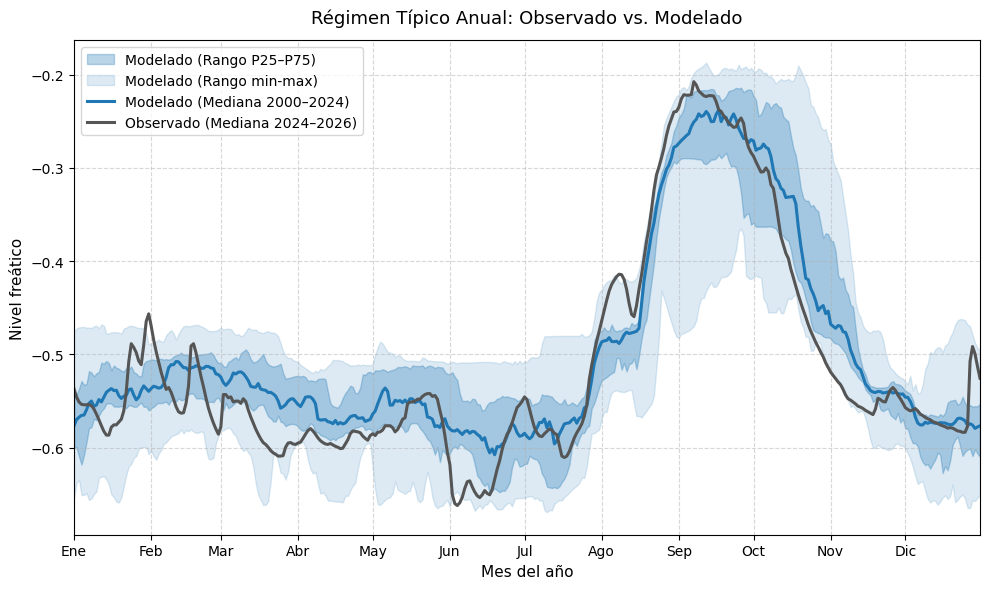

In [222]:
fig, ax = plot_annual_regime(modeled_df1, observed_df1)
plt.show()

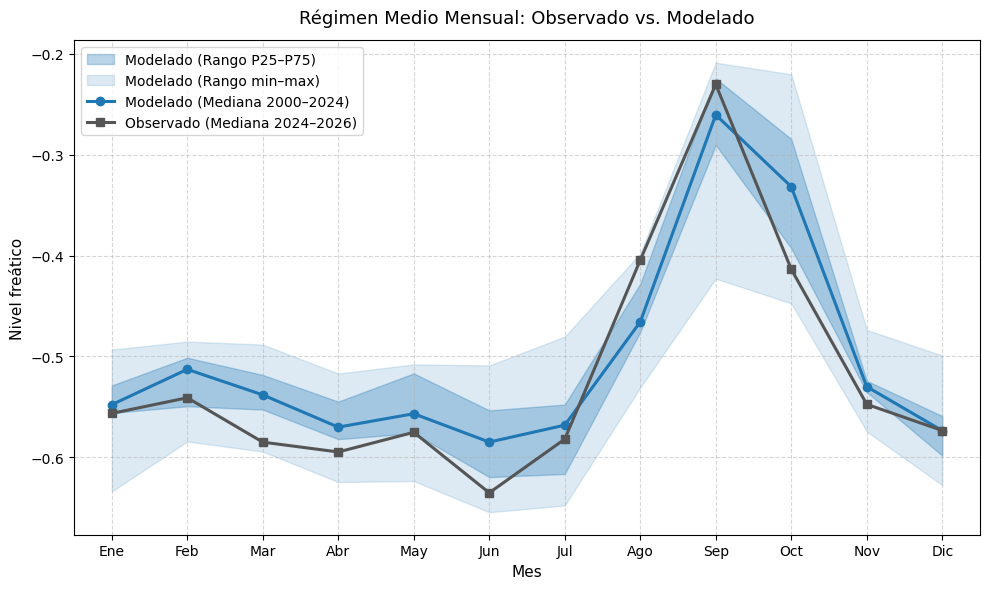

In [223]:
fig, ax = plot_annual_regime_monthly(modeled_df1, observed_df1)
plt.show()

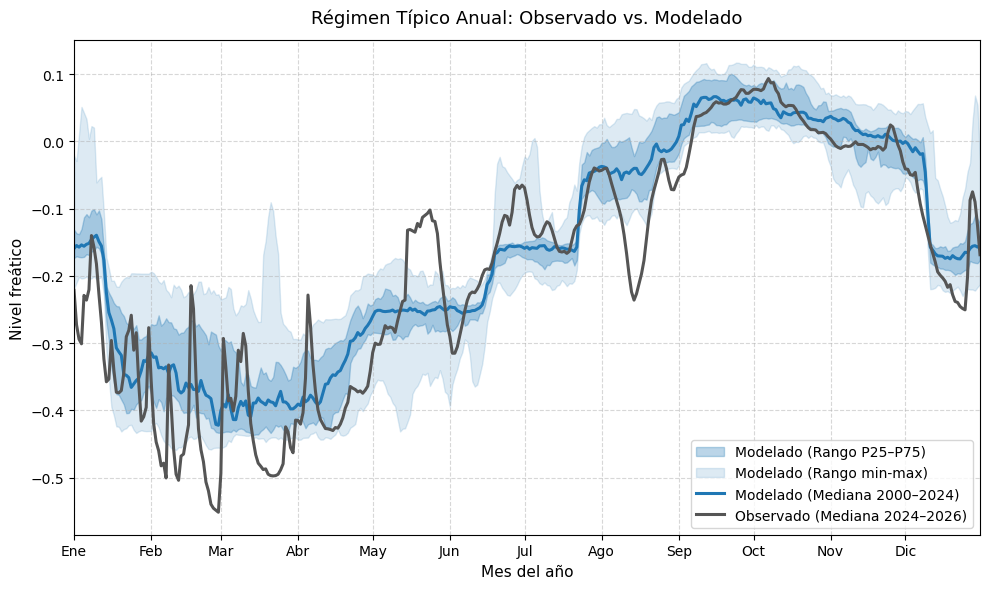

In [224]:
fig, ax = plot_annual_regime(modeled_df2, observed_df2)
plt.show()

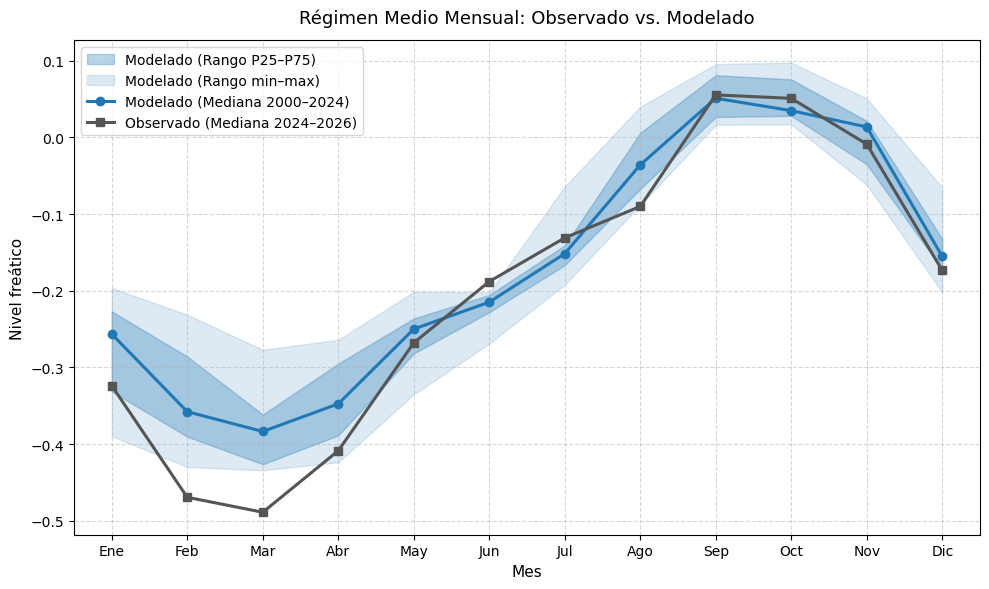

In [225]:
fig, ax = plot_annual_regime_monthly(modeled_df2, observed_df2)
plt.show()

In [226]:
def plot_water_table_distributions(
    modeled_df: pd.DataFrame,
    observed_df: pd.DataFrame,
    val_col: str = None,
    bins: int = 30,
):
    col_mod = val_col if val_col else modeled_df.columns[0]
    col_obs = val_col if val_col else observed_df.columns[0]

    # 1. Preparar series diarias y mensuales (agregadas por mediana)
    daily_mod = modeled_df[[col_mod]].dropna()
    daily_obs = observed_df[[col_obs]].dropna()

    monthly_mod = daily_mod.resample("MS").median().dropna()
    monthly_obs = daily_obs.resample("MS").median().dropna()

    # 2. Rango común para unificar los bines en ambas series
    all_vals = np.concatenate([daily_mod[col_mod], daily_obs[col_obs]])
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # 3. Función auxiliar para procesar y dibujar cada panel
    def render_panel(ax, mod_data, obs_data, title):
        # A. Distribución observada global (Histograma de densidad en barras)
        ax.hist(
            obs_data[obs_data.columns[0]],
            bins=bin_edges,
            density=True,
            color="#7f7f7f",
            alpha=0.55,
            edgecolor="white",
            linewidth=0.8,
            label="Observado (2024–2026)",
        )

        # B. Distribución del modelo desglosada por año
        yearly_densities = []
        for _, group in mod_data.groupby(mod_data.index.year):
            vals = group[group.columns[0]]
            if len(vals) > 5:  # Evitar años con muestras insuficientes
                counts, _ = np.histogram(vals, bins=bin_edges, density=True)
                yearly_densities.append(counts)

        dens_matrix = np.array(yearly_densities)  # Forma: (n_años, n_bines)

        # Percentiles a través de los años para cada bin
        p_min = np.min(dens_matrix, axis=0)
        p25 = np.percentile(dens_matrix, 25, axis=0)
        p50 = np.median(dens_matrix, axis=0)
        p75 = np.percentile(dens_matrix, 75, axis=0)
        p_max = np.max(dens_matrix, axis=0)

        # C. Envolventes del modelo
        ax.fill_between(
            bin_centers,
            p_min,
            p_max,
            color="#1f77b4",
            alpha=0.15,
            label="Modelado (Min–Max)",
        )
        ax.fill_between(
            bin_centers,
            p25,
            p75,
            color="#1f77b4",
            alpha=0.30,
            label="Modelado (P25–P75)",
        )

        # D. Línea central del modelo (Mediana interanual)
        ax.plot(
            bin_centers,
            p50,
            color="#1f77b4",
            linewidth=2.2,
            label="Modelado (Mediana interanual)",
        )

        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Profundidad del nivel freático (m)", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.4)

    # 4. Renderizar paneles
    render_panel(axes[0], daily_mod, daily_obs, "Distribución Diaria")
    render_panel(
        axes[1], monthly_mod, monthly_obs, "Distribución Mensual (Mediana)"
    )

    axes[0].set_ylabel("Densidad de frecuencia", fontsize=11)
    axes[0].legend(loc="upper right", frameon=True)
    axes[1].legend(loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, axes

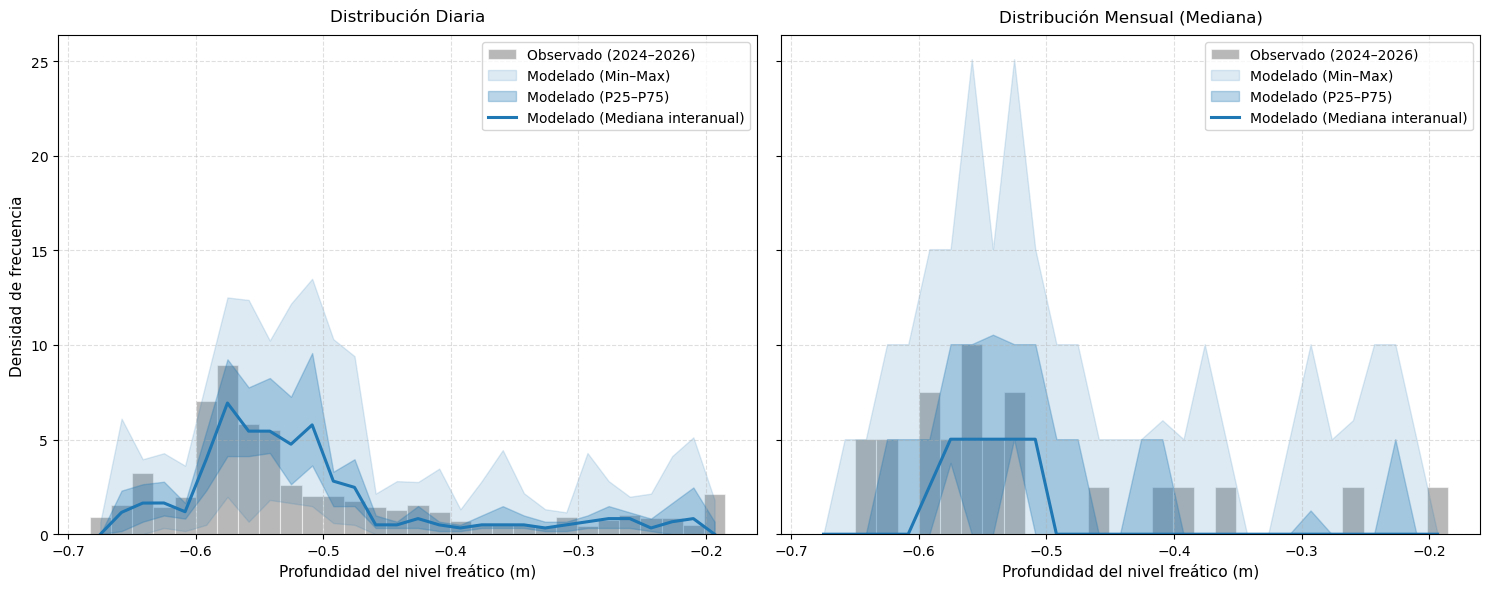

In [227]:
fig, axes = plot_water_table_distributions(modeled_df1, observed_df1, bins=30)
plt.show()

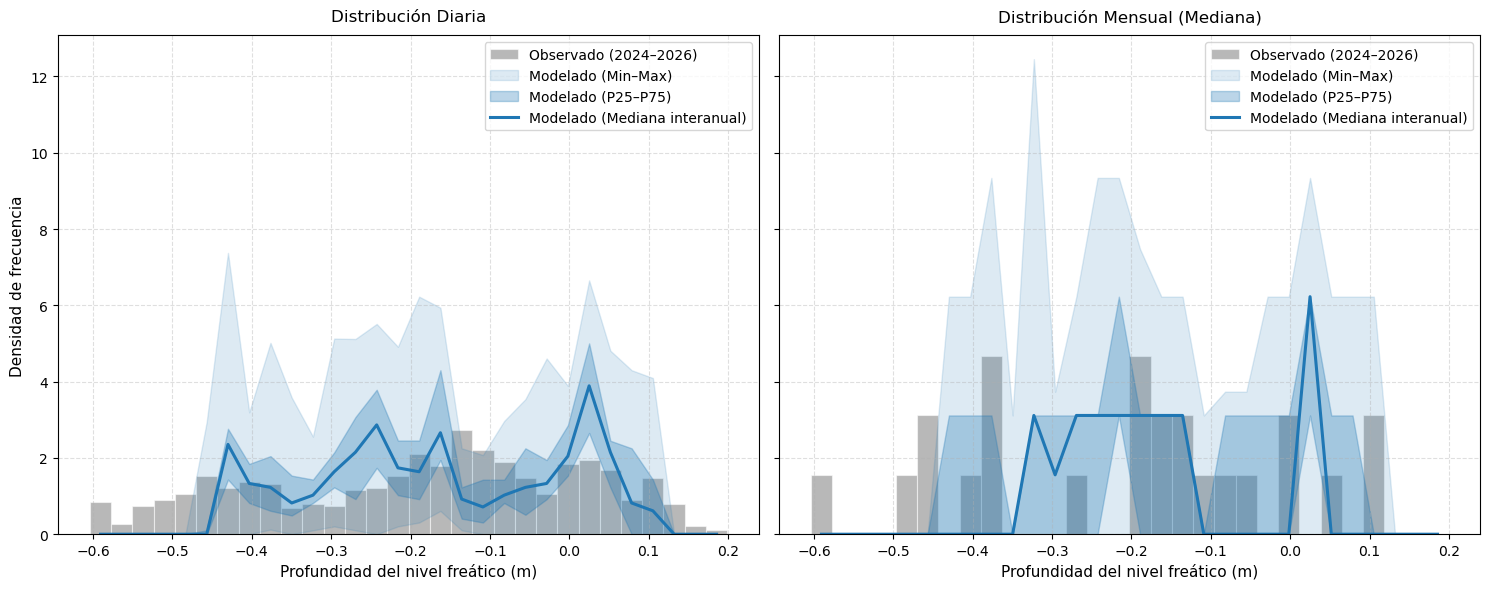

In [228]:
fig, axes = plot_water_table_distributions(modeled_df2, observed_df2, bins=30)
plt.show()

In [229]:
def plot_groundwater_sites_comparison(
    modeled_df1: pd.DataFrame,
    observed_df1: pd.DataFrame,
    modeled_df2: pd.DataFrame,
    observed_df2: pd.DataFrame,
    site1_name: str = "Sitio 1",
    site2_name: str = "Sitio 2",
    bins: int = 30,
):
    """Genera una figura 2x2 comparando el ciclo anual y la distribución de frecuencias

    de dos sitios a escala diaria con escalas unificadas entre sitios.
    """
    # 1. Paleta armónica diferenciada
    palette = {
        "s1": {
            "mod": "#1f77b4",
            "obs": "#343a40",
        },  # Azul petróleo y gris pizarra oscuro
        "s2": {
            "mod": "#d95f02",
            "obs": "#6c757d",
        },  # Naranja teja y gris medio frío
    }

    # 2. Extracción y limpieza de series diarias (sin bisiesto 366)
    def clean_series(df):
        s = df.iloc[:, 0].dropna()
        return s[s.index.dayofyear <= 365]

    s_m1, s_o1 = clean_series(modeled_df1), clean_series(observed_df1)
    s_m2, s_o2 = clean_series(modeled_df2), clean_series(observed_df2)

    # Rango global de profundidad para unificar bins y ejes entre sitios
    all_depths = np.concatenate([s_m1.values, s_o1.values, s_m2.values, s_o2.values])
    depth_pad = (all_depths.max() - all_depths.min()) * 0.05
    depth_min, depth_max = all_depths.min() - depth_pad, all_depths.max() + depth_pad
    bin_edges = np.linspace(depth_min, depth_max, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # 3. Métricas del ciclo anual (Día 1 a 365)
    def get_annual_stats(series):
        df_doy = pd.DataFrame({"val": series, "doy": series.index.dayofyear})
        return (
            df_doy.groupby("doy")["val"]
            .agg(
                median="median",
                q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75),
            )
            .reindex(range(1, 366))
        )

    # 4. Distribución interanual del modelo
    def get_modeled_distribution(series):
        densities = []
        for _, group in series.groupby(series.index.year):
            if len(group) > 30:
                counts, _ = np.histogram(group.values, bins=bin_edges, density=True)
                densities.append(counts)
        dens_arr = np.array(densities)
        return (
            np.percentile(dens_arr, 25, axis=0),
            np.median(dens_arr, axis=0),
            np.percentile(dens_arr, 75, axis=0),
        )

    # 5. Configuración de los 4 paneles
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex="col")
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = [
        "Ene", "Feb", "Mar", "Abr", "May", "Jun",
        "Jul", "Ago", "Sep", "Oct", "Nov", "Dic",
    ]

    sites_data = [
        ("s1", site1_name, s_m1, s_o1, axes[0, 0], axes[0, 1]),
        ("s2", site2_name, s_m2, s_o2, axes[1, 0], axes[1, 1]),
    ]

    for key, name, s_mod, s_obs, ax_ac, ax_dist in sites_data:
        c_mod, c_obs = palette[key]["mod"], palette[key]["obs"]

        # --- PANEL IZQUIERDA: CICLO ANUAL ---
        st_mod = get_annual_stats(s_mod)
        st_obs = get_annual_stats(s_obs)

        # Envolventes P25-P75
        ax_ac.fill_between(
            st_mod.index,
            st_mod["q25"],
            st_mod["q75"],
            color=c_mod,
            alpha=0.22,
            label="Mod. P25–P75",
        )
        ax_ac.fill_between(
            st_obs.index,
            st_obs["q25"],
            st_obs["q75"],
            color=c_obs,
            alpha=0.18,
            label="Obs. P25–P75",
        )

        # Líneas medianas (modelada segmentada, observada continua)
        ax_ac.plot(
            st_mod.index,
            st_mod["median"],
            color=c_mod,
            linestyle="--",
            linewidth=2,
            label="Mod. Mediana",
        )
        ax_ac.plot(
            st_obs.index,
            st_obs["median"],
            color=c_obs,
            linestyle="-",
            linewidth=2,
            label="Obs. Mediana",
        )

        ax_ac.set_title(f"{name} — Ciclo Anual Típico", fontsize=12, pad=8)
        ax_ac.set_ylabel("Nivel freático (m)", fontsize=10)
        ax_ac.set_xlim(1, 365)
        ax_ac.set_xticks(month_starts)
        ax_ac.set_xticklabels(month_names)
        ax_ac.grid(True, linestyle="--", alpha=0.4)
        ax_ac.legend(loc="best", fontsize=8.5, frameon=True)

        # --- PANEL DERECHA: DISTRIBUCIÓN DE FRECUENCIA ---
        # Observado en barras
        ax_dist.hist(
            s_obs.values,
            bins=bin_edges,
            density=True,
            color=c_obs,
            alpha=0.45,
            edgecolor="white",
            linewidth=0.6,
            label="Obs. Distribución",
        )

        # Modelado: P25-P75 interanual y mediana segmentada
        p25_dens, med_dens, p75_dens = get_modeled_distribution(s_mod)
        ax_dist.fill_between(
            bin_centers,
            p25_dens,
            p75_dens,
            color=c_mod,
            alpha=0.25,
            label="Mod. P25–P75",
        )
        ax_dist.plot(
            bin_centers,
            med_dens,
            color=c_mod,
            linestyle="--",
            linewidth=2,
            label="Mod. Mediana",
        )

        ax_dist.set_title(f"{name} — Densidad de Frecuencia", fontsize=12, pad=8)
        ax_dist.set_ylabel("Densidad", fontsize=10)
        ax_dist.grid(True, linestyle="--", alpha=0.4)
        ax_dist.legend(loc="upper right", fontsize=8.5, frameon=True)

    # 6. Unificar escalas verticales y horizontales entre sitios
    # Escala de profundidad compartida
    for ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylim(depth_min, depth_max)

    for ax in [axes[0, 1], axes[1, 1]]:
        ax.set_xlim(depth_min, depth_max)

    # Escala de densidad compartida
    max_dens = max(axes[0, 1].get_ylim()[1], axes[1, 1].get_ylim()[1])
    axes[0, 1].set_ylim(0, max_dens)
    axes[1, 1].set_ylim(0, max_dens)

    axes[1, 0].set_xlabel("Mes del año", fontsize=11)
    axes[1, 1].set_xlabel("Nivel freático (m)", fontsize=11)

    plt.tight_layout()
    return fig, axes

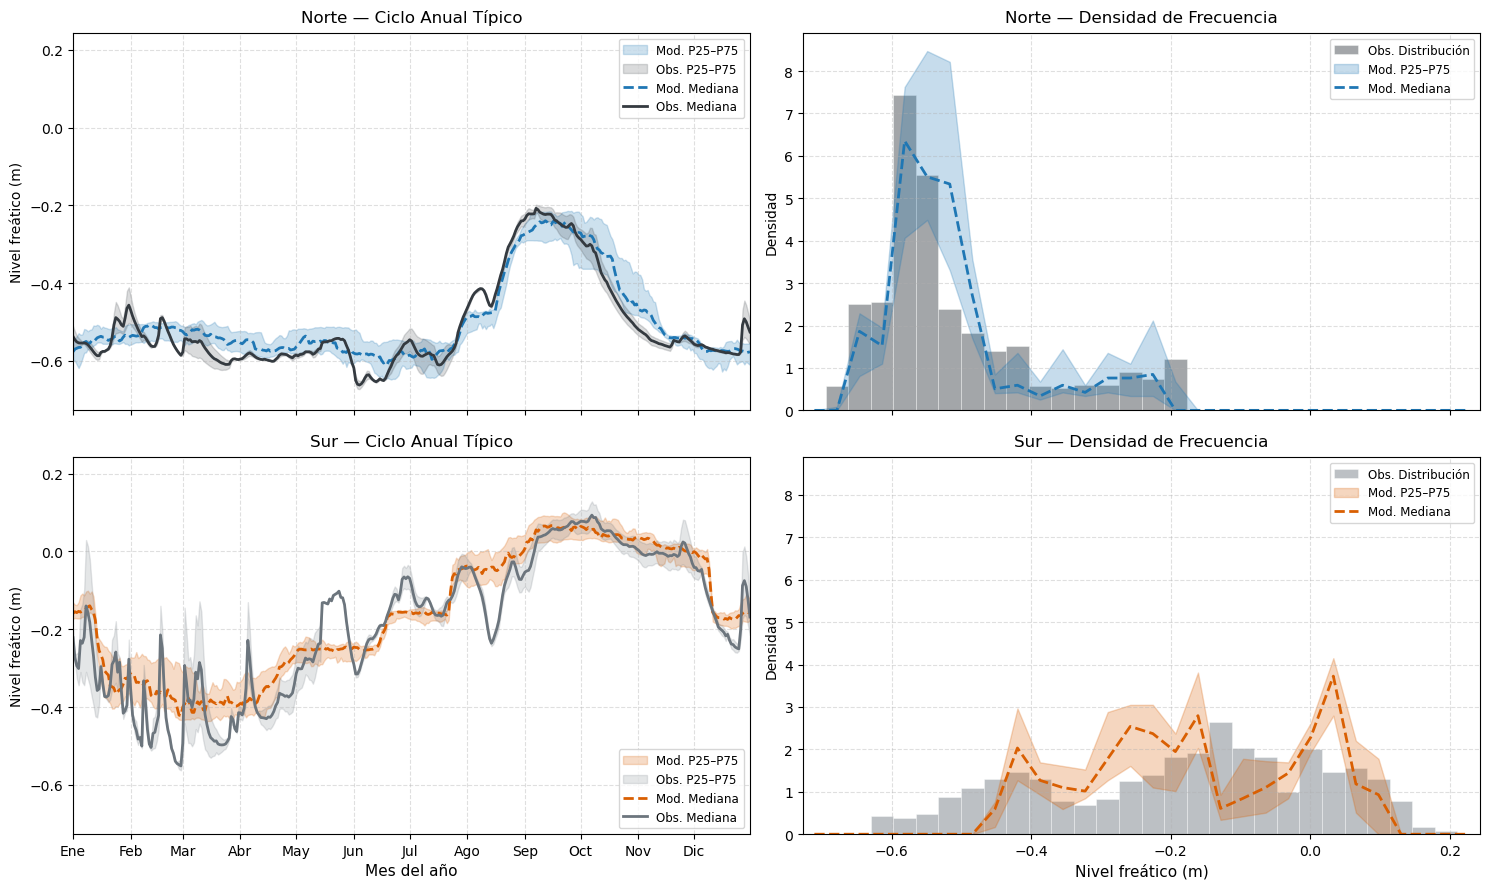

In [231]:
fig, axes = plot_groundwater_sites_comparison(
    modeled_df1, observed_df1,
    modeled_df2, observed_df2,
    site1_name="Norte", site2_name="Sur",
    bins=30
)
plt.show()

In [251]:
def plot_groundwater_sites_comparison(
    modeled_df1: pd.DataFrame,
    observed_df1: pd.DataFrame,
    modeled_df2: pd.DataFrame,
    observed_df2: pd.DataFrame,
    site1_name: str = "Sitio 1",
    site2_name: str = "Sitio 2",
    bins: int = 30,
):
    """Genera una figura 2x2 comparando el ciclo anual y la distribución de frecuencias.

    El eje Y (profundidad) se comparte por fila entre el ciclo anual y la
    densidad (horizontal).
    """
    # 1. Paleta armónica diferenciada
    palette = {
        "s1": {"mod": "#1f77b4", "obs": "#343a40"},  # Azul petróleo y gris pizarra
        "s2": {"mod": "#d95f02", "obs": "#6c757d"},  # Naranja teja y gris frío
    }

    # 2. Extracción y limpieza (sin día bisiesto 366)
    def clean_series(df):
        s = df.iloc[:, 0].dropna()
        return s[s.index.dayofyear <= 365]

    s_m1, s_o1 = clean_series(modeled_df1), clean_series(observed_df1)
    s_m2, s_o2 = clean_series(modeled_df2), clean_series(observed_df2)

    # Rango unificado de profundidad para todos los paneles
    all_depths = np.concatenate([s_m1.values, s_o1.values, s_m2.values, s_o2.values])
    depth_pad = (all_depths.max() - all_depths.min()) * 0.05
    depth_min, depth_max = all_depths.min() - depth_pad, all_depths.max() + depth_pad
    bin_edges = np.linspace(depth_min, depth_max, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # 3. Estadísticas del ciclo anual (1 a 365 días)
    def get_annual_stats(series):
        df_doy = pd.DataFrame({"val": series, "doy": series.index.dayofyear})
        return (
            df_doy.groupby("doy")["val"]
            .agg(
                median="median",
                q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75),
                v_min="min",
                v_max="max",
            )
            .reindex(range(1, 366))
        )

    # 4. Distribución interanual del modelo por cada bin
    def get_modeled_distribution(series):
        densities = []
        for _, group in series.groupby(series.index.year):
            if len(group) > 30:
                counts, _ = np.histogram(group.values, bins=bin_edges, density=True)
                densities.append(counts)
        dens_arr = np.array(densities)
        return (
            np.min(dens_arr, axis=0),
            np.percentile(dens_arr, 25, axis=0),
            np.median(dens_arr, axis=0),
            np.percentile(dens_arr, 75, axis=0),
            np.max(dens_arr, axis=0),
        )

    # 5. Crear figura con ratios de ancho: el ciclo anual suele necesitar más espacio que la densidad
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9),
        sharey="row",
        gridspec_kw={"width_ratios": [2.5, 1.3]},
    )

    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = [
        "Ene",
        "Feb",
        "Mar",
        "Abr",
        "May",
        "Jun",
        "Jul",
        "Ago",
        "Sep",
        "Oct",
        "Nov",
        "Dic",
    ]

    sites_data = [
        ("s1", site1_name, s_m1, s_o1, axes[0, 0], axes[0, 1]),
        ("s2", site2_name, s_m2, s_o2, axes[1, 0], axes[1, 1]),
    ]

    max_dens_found = 0.0

    for key, name, s_mod, s_obs, ax_ac, ax_dist in sites_data:
        c_mod, c_obs = palette[key]["mod"], palette[key]["obs"]

        # --- PANEL IZQUIERDA: CICLO ANUAL ---
        st_mod = get_annual_stats(s_mod)
        st_obs = get_annual_stats(s_obs)

        # Envolventes del modelo: Min-Max (suave) y P25-P75
        ax_ac.fill_between(
            st_mod.index,
            st_mod["v_min"],
            st_mod["v_max"],
            color=c_mod,
            alpha=0.12,
            label="min–max",
        )
        ax_ac.fill_between(
            st_mod.index,
            st_mod["q25"],
            st_mod["q75"],
            color=c_mod,
            alpha=0.25,
            label="p25–p75",
        )

        # Líneas medianas (observado solo línea continua, sin sombreado)
        ax_ac.plot(
            st_mod.index,
            st_mod["median"],
            color=c_mod,
            linestyle="--",
            linewidth=1.2,
            label="Modelado: p50",
        )
        ax_ac.plot(
            st_obs.index,
            st_obs["median"],
            color=c_obs,
            linestyle="-",
            linewidth=2,
            label="Observado: p50",
        )

        ax_ac.set_title(f"{name} — Ciclo anual", fontsize=12, pad=8)
        ax_ac.set_ylabel("Profundidad nivel freático (m)", fontsize=10)
        ax_ac.set_xlim(1, 365)
        ax_ac.set_xticks(month_starts)
        ax_ac.set_xticklabels(month_names)
        ax_ac.grid(True, linestyle="--", alpha=0.4)
        #ax_ac.legend(loc="best", fontsize=8.5, frameon=True)

        # --- PANEL DERECHA: DISTRIBUCIÓN HORIZONTAL (Eje Y = Profundidad) ---
        # Barras observadas horizontales
        counts_obs, _, _ = ax_dist.hist(
            s_obs.values,
            bins=bin_edges,
            density=True,
            orientation="horizontal",
            color=c_obs,
            alpha=0.45,
            edgecolor="white",
            linewidth=0.6,
            label="Observado",
        )

        # Modelado horizontal: bandas y mediana a lo largo del eje Y (bin_centers)
        p_min, p25, med, p75, p_max = get_modeled_distribution(s_mod)

        ax_dist.fill_betweenx(
            bin_centers,
            p_min,
            p_max,
            color=c_mod,
            alpha=0.12,
            label="min–max",
        )
        ax_dist.fill_betweenx(
            bin_centers,
            p25,
            p75,
            color=c_mod,
            alpha=0.25,
            label="p25-p75",
        )
        ax_dist.plot(
            med,
            bin_centers,
            color=c_mod,
            linestyle="--",
            linewidth=1.2,
            label="Modelado: q50",
        )

        ax_dist.set_title(f"{name} — Densidad de frecuencia", fontsize=12, pad=8)
        ax_dist.grid(True, linestyle="--", alpha=0.4)
        ax_dist.legend(loc="upper right", fontsize=8.5, frameon=True)

        # Rastrear máxima densidad para compartir escala horizontal
        current_max = max(counts_obs.max(), p_max.max())
        if current_max > max_dens_found:
            max_dens_found = current_max

    # 6. Homogeneizar escalas entre todos los paneles
    for ax_row in axes:
        for ax in ax_row:
            ax.set_ylim(depth_min, depth_max)

    # Compartir escala en eje X de densidad (columna derecha)
    axes[0, 1].set_xlim(0, max_dens_found * 1.08)
    axes[1, 1].set_xlim(0, max_dens_found * 1.08)

    axes[1, 0].set_xlabel("Mes del año", fontsize=11)
    axes[1, 1].set_xlabel("Densidad de frecuencia", fontsize=11)

    plt.tight_layout()
    return fig, axes


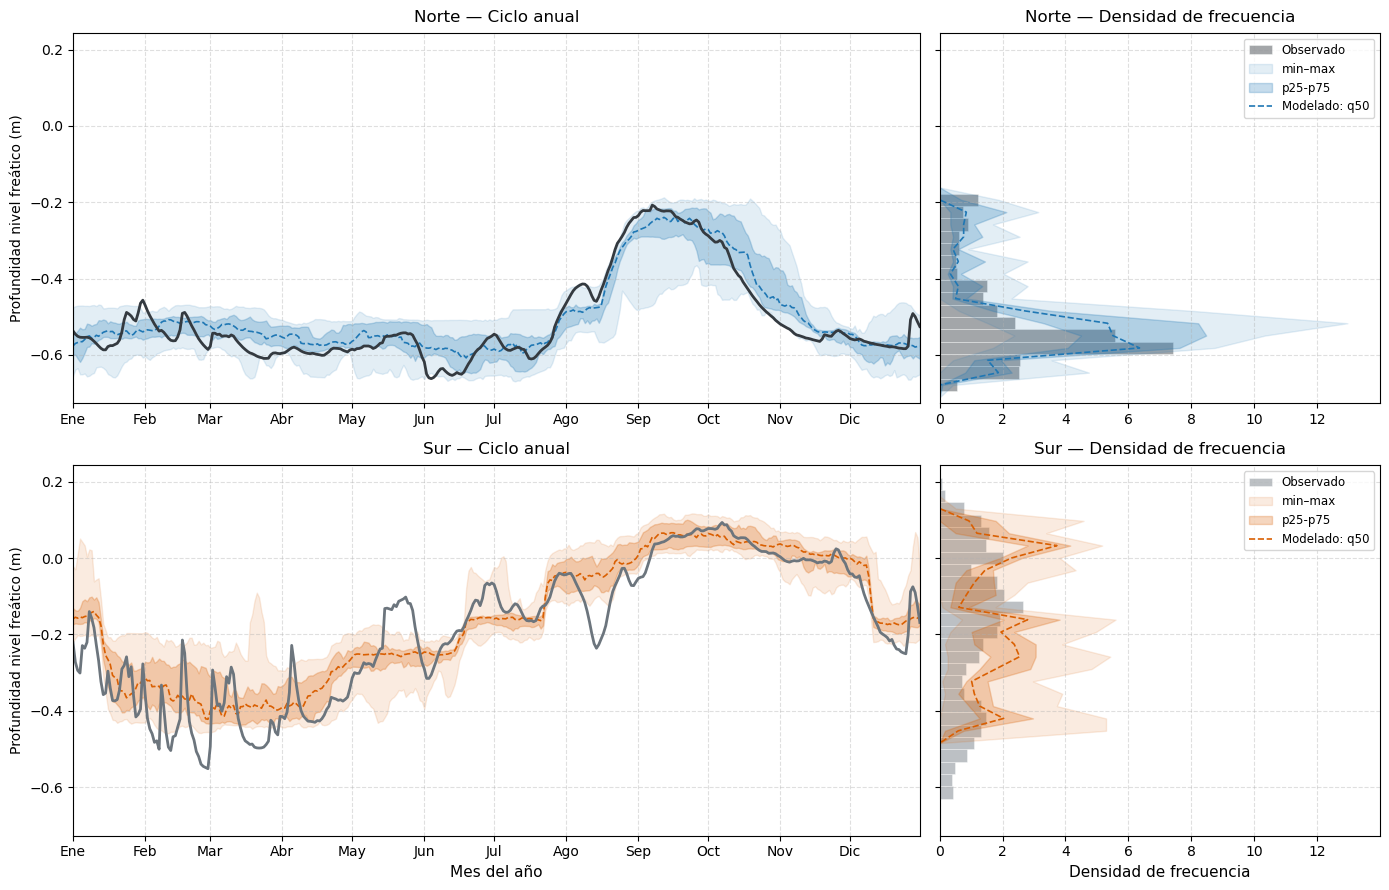

In [252]:
fig, axes = plot_groundwater_sites_comparison(
    modeled_df1, observed_df1,
    modeled_df2, observed_df2,
    site1_name="Norte", site2_name="Sur",
    bins=30
)
plt.show()